In [ ]:
!apt-get install -y tesseract-ocr
!pip install pytesseract pdf2image opencv-python pillow numpy pymupdf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 79.7 MB/s eta 0:00:00


In [ ]:
import fitz
import cv2
import pytesseract
import numpy as np
from PIL import Image

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]
print(f"\nPDF uploaded successfully! Path: {pdf_path}")


doc = fitz.open(pdf_path)
print(f"Doc has {len(doc)} pages.")

Saving pharmaceutical-sdf-page4-certificate-processing.pdf to pharmaceutical-sdf-page4-certificate-processing (1).pdf

PDF uploaded successfully! Path: pharmaceutical-sdf-page4-certificate-processing (1).pdf
Doc has 1 pages.


In [ ]:
page = doc[0]
text = page.get_text("text")

print("Attempting direct text extraction (without OCR):")
print("-" * 50)
if text.strip():
  print(text[:500])

else:
  print("[EMPTY]! No text found! This PDF is a scanned image.")
  print("This is why we need to use OCR (optical character recognition) - To read the picture as a text.")

Attempting direct text extraction (without OCR):
--------------------------------------------------
[EMPTY]! No text found! This PDF is a scanned image.
This is why we need to use OCR (optical character recognition) - To read the picture as a text.


Here is your pharmaceutical document as an image!


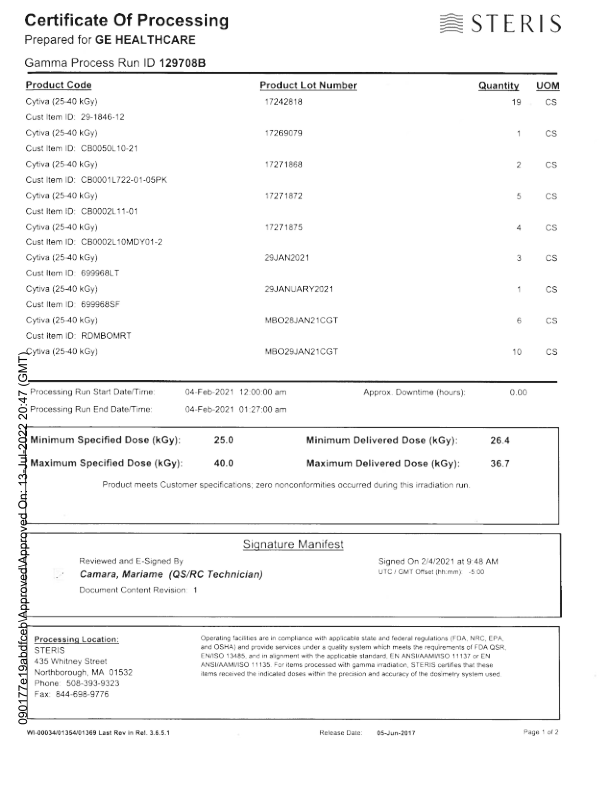

In [ ]:
pix = page.get_pixmap()
img = np.array(Image.frombytes("RGB", [pix.width, pix.height], pix.samples))

print("Here is your pharmaceutical document as an image!")
display(Image.fromarray(img))

Grayscale Version (colour removed: )


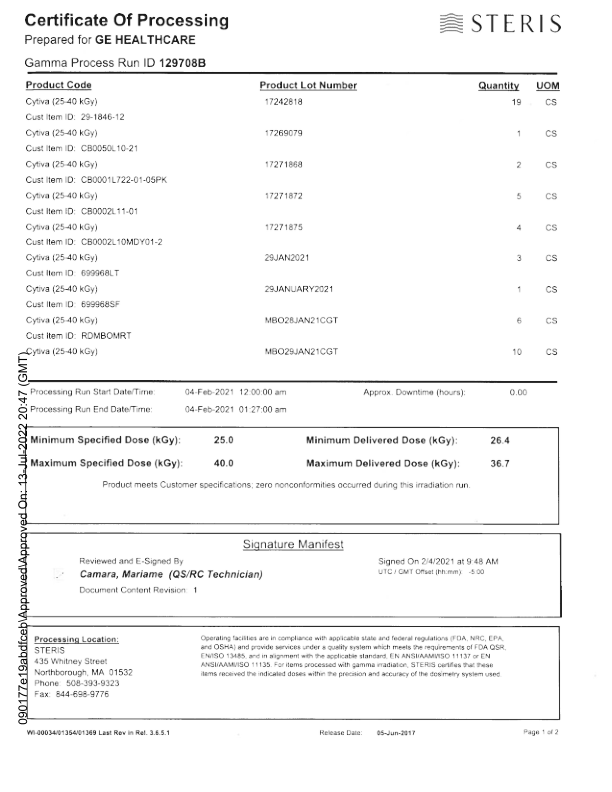

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("Grayscale Version (colour removed: )")
display(Image.fromarray(gray))

After thresholding (high contrast):  


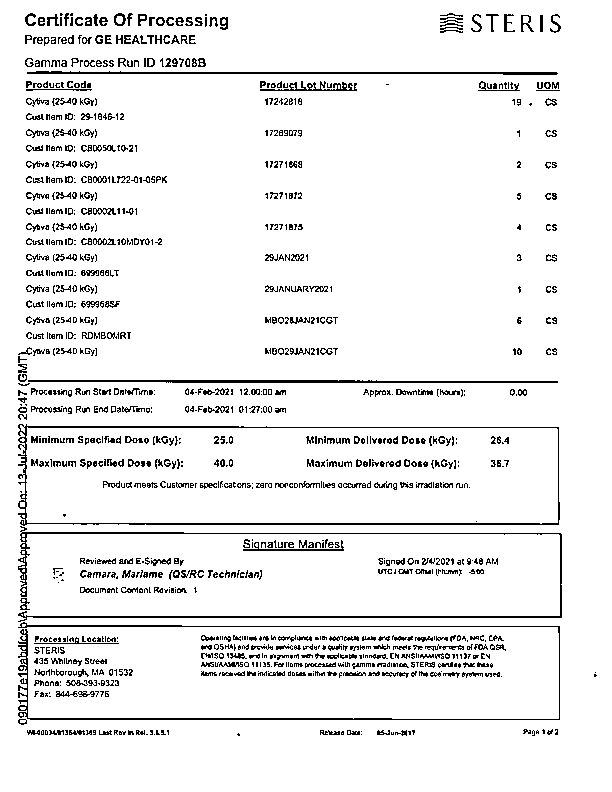

In [ ]:
gray = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

print("After thresholding (high contrast):  ")
display(Image.fromarray(gray))

After resizing (smaller):  


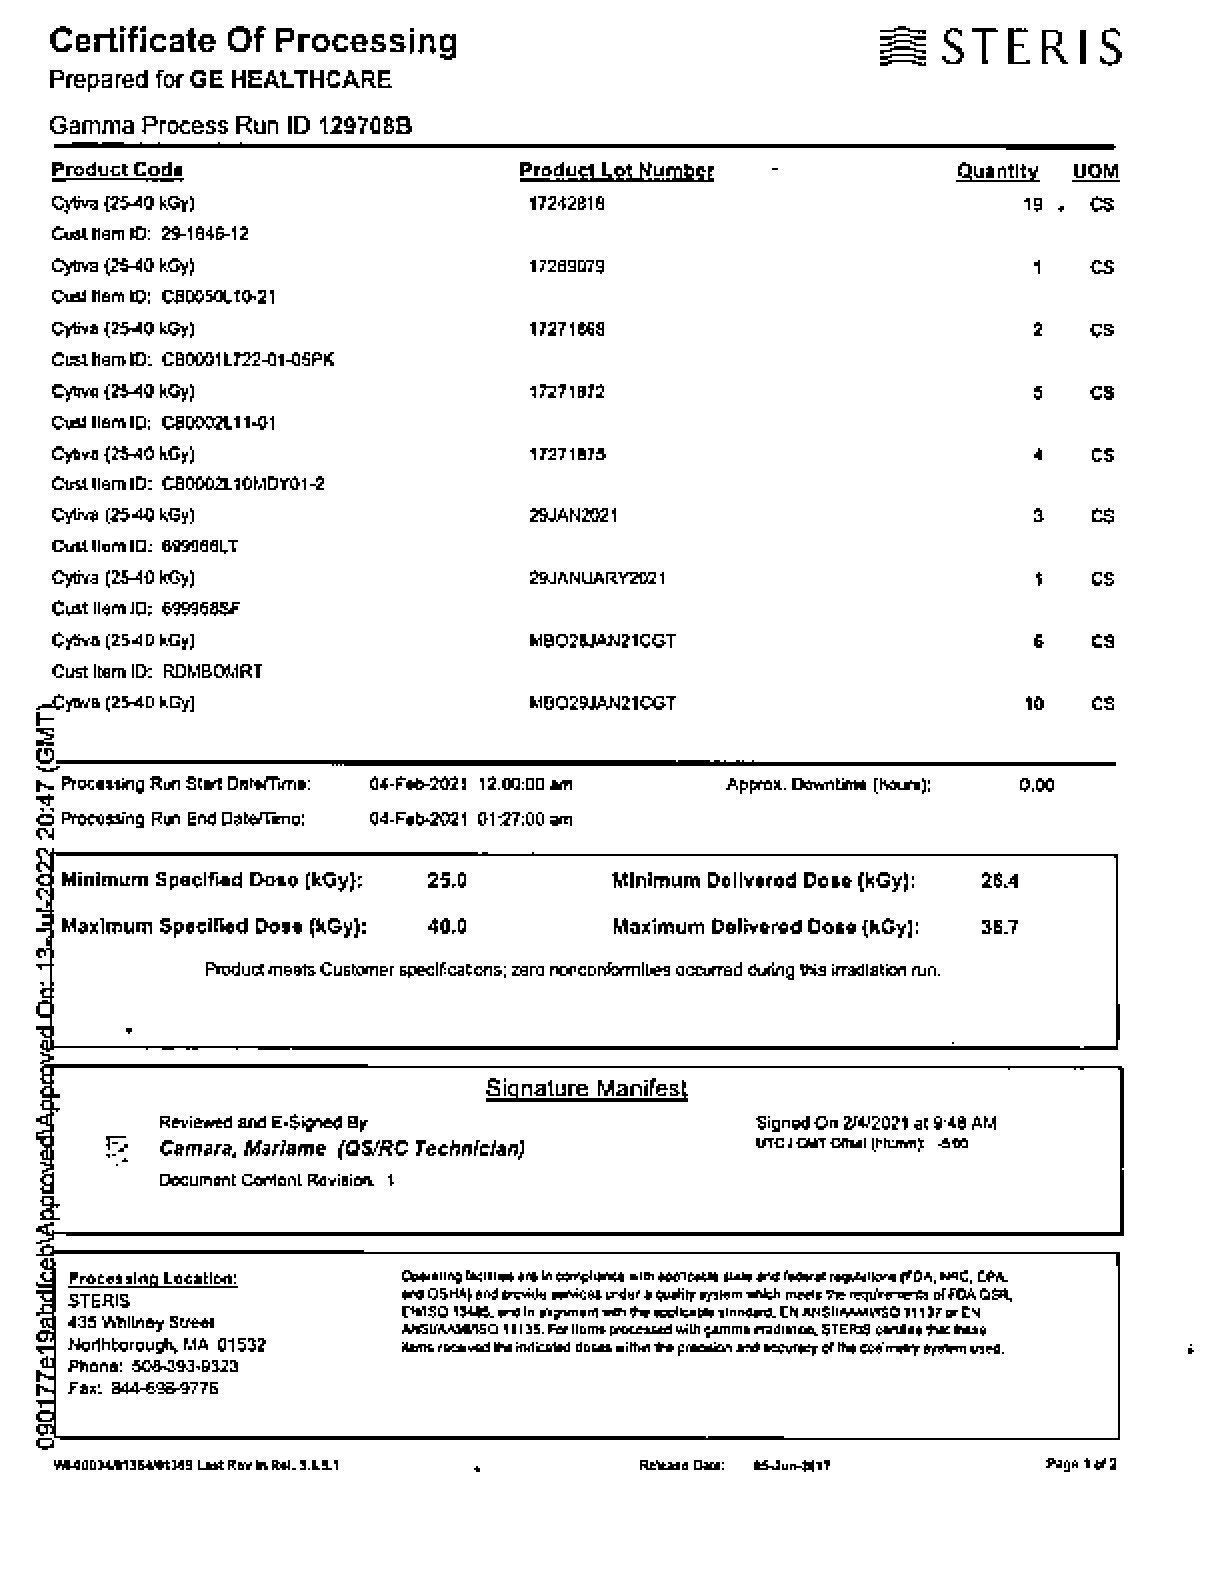

In [ ]:
scale_percent = 200
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)

gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_AREA)
gray = cv2.fastNlMeansDenoising(gray, h=10)
print("After resizing (smaller):  ")
display(Image.fromarray(gray))

In [ ]:
custom_config = r'--oem 3 -l eng'

ocr_text = pytesseract.image_to_string(gray, config=custom_config)

print("=" * 50)
print("OCR EXTRACTED TEXT")
print("=" * 50)
print(ocr_text)

OCR EXTRACTED TEXT
Certificate Of Processing = STERIS
Prepared for GE HEALTHCARE

Gamma Process Run ID 1297088

 

   
   

 

 

Product Co dur Lot Number - Quantity UOM
Oytva (249 kGy) 1242016 Wa. oS
Casita Ho: 29-1646-12
Cyiva 2540 boy} 17289079 1. os
Cx Harn tO) CANS 10-21
Sytva (2540 ky] 127 1669 2 cs
Cuztham iO: CHOGOILT22-01-046PK
Cytve (249 by) U2P ale i cs
Cu Heri; CADDO2L 11-91
Cybern (246 hGy) ATSTIMIS 4s
Crt lamID: CAOGiALIOMo rH -2
Cyl (2500 kGy) 2RIANDI2 1 a eS
Cutt Vom IO: Ge0d6LT
Cytiva (240 ky) DQUANUARY2O21 + os
Cust lam: Boga
Oya (25-40 Gy) MBO?RBN2ICGT & eg
‘Cust Ibam ID: ROMBOWMRT

prs [25-40 ky] MBQ2MANZICGT 10 es

=

o-

Ld Procesang Run Stet DateTime: 04-Feb-2021 12.00:00 an Apprad. Denwrititrien [houre): 8.00

s Procusaing Run End DateTeno: O4-Fete2d 1 27:00 am

 

Minimum Spacifiad Doug (kGy}: 25.0 Minimum Dellverod Dore (kGy]: 264
Maximum Specified Dose (Gy): 40.0 Mazinum Delivered Come (hy): 367

Product meets Customer speciicatens; zara norcondarmibes dcter

In [ ]:
import re

ocr_clean_text = " ".join (ocr_text.split())

ocr_clean_text = re.sub(r'\bL0T\b', 'LOT', ocr_clean_text, flags=re.IGNORECASE)
ocr_clean_text = re.sub(r'\bC0A\b', 'COA', ocr_clean_text, flags=re.IGNORECASE)
ocr_clean_text = re.sub(r'\bCERT1FICATE\b', 'CERTIFICATE', ocr_clean_text, flags=re.IGNORECASE)
ocr_clean_text = re.sub(r'\bEXP1RATION\b', 'EXPIRATION', ocr_clean_text, flags=re.IGNORECASE)
ocr_clean_text = re.sub(r'\bPR0CESSING\b', 'PROCESSING', ocr_clean_text, flags=re.IGNORECASE)
ocr_clean_text = re.sub(r'\bMANUFACTUR1NG\b', 'MANUFACTURING', ocr_clean_text, flags=re.IGNORECASE)

ocr_clean_text = re.sub(r'[^a-zA-Z0-9\s,.%-/:]', '', ocr_clean_text)

print("=" * 50)
print("OCR CLEANED TEXT")
print("=" * 50)
print(ocr_clean_text)

OCR CLEANED TEXT
Certificate Of Processing  STERIS Prepared for GE HEALTHCARE Gamma Process Run ID 1297088 Product Co dur Lot Number - Quantity UOM Oytva (249 kGy) 1242016 Wa. oS Casita Ho: 29-1646-12 Cyiva 2540 boy 17289079 1. os Cx Harn tO) CANS 10-21 Sytva (2540 ky 127 1669 2 cs Cuztham iO: CHOGOILT22-01-046PK Cytve (249 by) U2P ale i cs Cu Heri CADDO2L 11-91 Cybern (246 hGy) ATSTIMIS 4s Crt lamID: CAOGiALIOMo rH -2 Cyl (2500 kGy) 2RIANDI2 1 a eS Cutt Vom IO: Ge0d6LT Cytiva (240 ky) DQUANUARY2O21 + os Cust lam: Boga Oya (25-40 Gy) MBORBN2ICGT & eg Cust Ibam ID: ROMBOWMRT prs 25-40 ky MBQ2MANZICGT 10 es  o- Ld Procesang Run Stet DateTime: 04-Feb-2021 12.00:00 an Apprad. Denwrititrien houre): 8.00 s Procusaing Run End DateTeno: O4-Fete2d 1 27:00 am Minimum Spacifiad Doug (kGy: 25.0 Minimum Dellverod Dore (kGy: 264 Maximum Specified Dose (Gy): 40.0 Mazinum Delivered Come (hy): 367 Product meets Customer speciicatens zara norcondarmibes dcterrad ching tha irradiation run. Signature Mani

In [ ]:
ocr_data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)
print("Sample of words detected with bounding boxes.")
print("-" * 60)

count = 0
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip()
    if word:
        x = ocr_data["left"][i]
        y = ocr_data["top"][i]
        w = ocr_data["width"][i]
        h = ocr_data["height"][i]
        conf = ocr_data["conf"][i]
        print(f"Word: '{word}' Position: ({x}, {y}) Size: {w}x{h} Confidence: {conf}")
        count += 1
    if count >= 10:
        break

print(f"\n...and {len([t for t in ocr_data['text'] if t.strip()])} total words detected!")

Sample of words detected with bounding boxes.
------------------------------------------------------------
Word: 'Certificate' Position: (50, 26) Size: 166x26 Confidence: 96
Word: 'Of' Position: (228, 26) Size: 38x26 Confidence: 96
Word: 'Processing' Position: (276, 28) Size: 180x32 Confidence: 96
Word: '=' Position: (880, 26) Size: 46x40 Confidence: 31
Word: 'STERIS' Position: (942, 28) Size: 180x38 Confidence: 31
Word: 'Prepared' Position: (50, 70) Size: 98x22 Confidence: 96
Word: 'for' Position: (156, 70) Size: 28x18 Confidence: 95
Word: 'GE' Position: (190, 70) Size: 34x18 Confidence: 95
Word: 'HEALTHCARE' Position: (232, 70) Size: 160x18 Confidence: 94
Word: 'Gamma' Position: (50, 116) Size: 84x18 Confidence: 89

...and 293 total words detected!


All detected words with bounding boxes (green):  


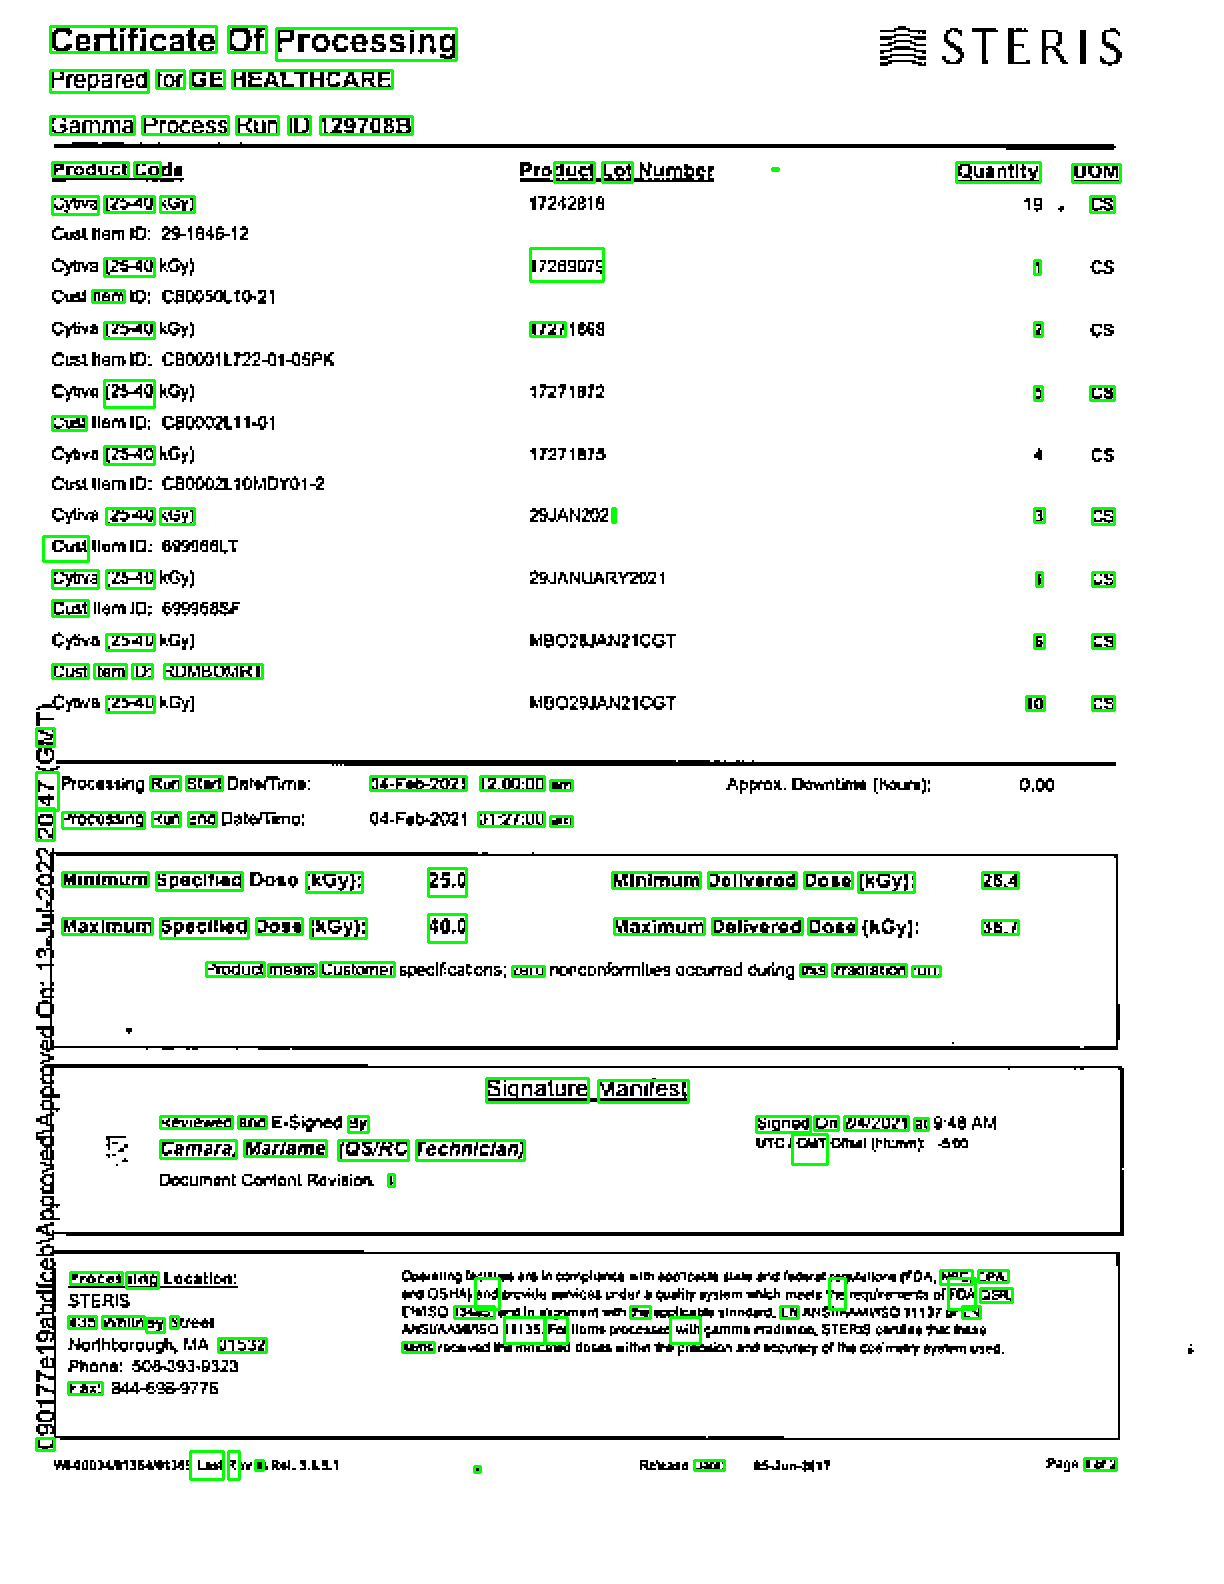

In [ ]:
img_with_boxes = cv2.cvtColor(gray.copy(), cv2.COLOR_GRAY2BGR)

confidence_level = 40

for i in range(len(ocr_data["text"])):
  word = ocr_data["text"][i].strip()
  conf = int(ocr_data["conf"][i])

  if not word or conf < confidence_level:
    continue

  x = ocr_data["left"][i]
  y = ocr_data["top"][i]
  w = ocr_data["width"][i]
  h = ocr_data["height"][i]

  cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

print("All detected words with bounding boxes (green):  ")
display(Image.fromarray(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)))


Highlighted 12 key fields (red):  


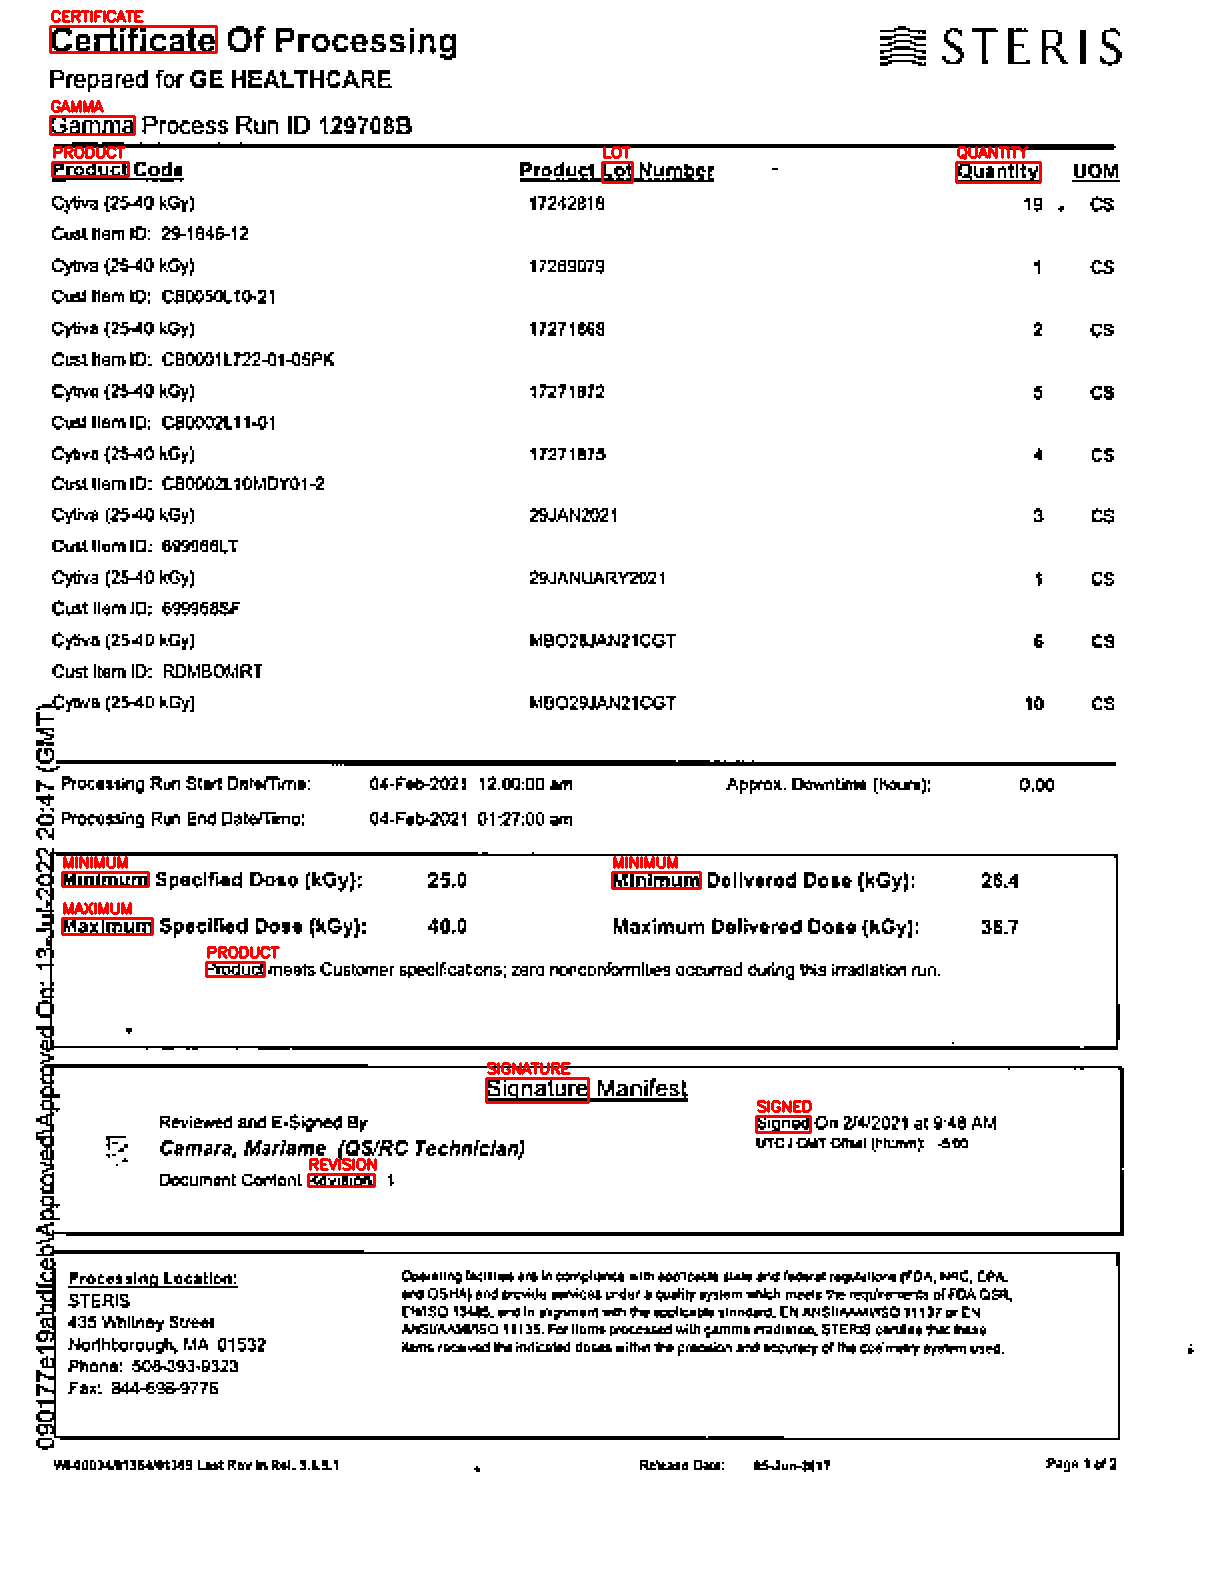

In [ ]:
key_fields = [
    "CERTIFICATE",
    "LOT",
    "BATCH",
    "VENDOR",
    "EXPIRATION",
    "DATE",
    "COA",
    "MANUFACTURER",
    "STERIS"
    "PROCESSING",
    "QUALITY"
    "CYTIVA",
    "GAMMA",
    "SIGNATURE",
    "SIGNED",
    "CAMARA",
    "REVISION",
    "PRODUCT",
    "QUANTITY",
    "MINIMUM",
    "MAXIMUM"
]

img_key_fields = cv2.cvtColor(gray.copy(), cv2.COLOR_GRAY2BGR)

highlighted_areas = 0
for i in range(len(ocr_data["text"])):
  word = ocr_data["text"][i].strip().upper()
  if word in key_fields:
    x = ocr_data["left"][i]
    y = ocr_data["top"][i]
    w = ocr_data["width"][i]
    h = ocr_data["height"][i]
    cv2.rectangle(img_key_fields, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.putText(img_key_fields, word, (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    highlighted_areas += 1

print(f"Highlighted {highlighted_areas} key fields (red):  ")
display(Image.fromarray(cv2.cvtColor(img_key_fields, cv2.COLOR_BGR2RGB)))

In [ ]:
import json

extracted_data = {}

for i in range(len(ocr_data["text"])):
  word = ocr_data["text"][i].strip().upper()

  if word in key_fields:
    x = ocr_data["left"][i]
    y = ocr_data["top"][i]
    w = ocr_data["width"][i]
    h = ocr_data["height"][i]

    extracted_data[word] = {
        "text": word,
        "bounding_box": y,
        "confidence": conf
    }

json_output = json.dumps(extracted_data, indent=4)
print("=" * 50)
print("EXTRACTED KEY FIELDS IN JSON FORMATTING")
print("=" * 50)
print(json_output)

EXTRACTED KEY FIELDS IN JSON FORMATTING
{
    "CERTIFICATE": {
        "text": "CERTIFICATE",
        "bounding_box": 26,
        "confidence": 46
    },
    "GAMMA": {
        "text": "GAMMA",
        "bounding_box": 116,
        "confidence": 46
    },
    "PRODUCT": {
        "text": "PRODUCT",
        "bounding_box": 962,
        "confidence": 46
    },
    "LOT": {
        "text": "LOT",
        "bounding_box": 162,
        "confidence": 46
    },
    "QUANTITY": {
        "text": "QUANTITY",
        "bounding_box": 162,
        "confidence": 46
    },
    "MINIMUM": {
        "text": "MINIMUM",
        "bounding_box": 872,
        "confidence": 46
    },
    "MAXIMUM": {
        "text": "MAXIMUM",
        "bounding_box": 918,
        "confidence": 46
    },
    "SIGNATURE": {
        "text": "SIGNATURE",
        "bounding_box": 1078,
        "confidence": 46
    },
    "SIGNED": {
        "text": "SIGNED",
        "bounding_box": 1116,
        "confidence": 46
    },
    "REVISIO